# Modélisation et sélection du modèle

## 1. Introduction et objectifs

L’analyse exploratoire a permis d’identifier les variables les plus liées au score d’examen et de définir une stratégie de prétraitement.
Ce notebook poursuit le projet en mettant en œuvre la phase de modélisation.

L’objectif est de construire un modèle prédictif capable d’estimer Exam_Score à partir des caractéristiques des étudiants.
Pour cela, plusieurs familles de modèles de régression seront testées, comparées et optimisées, afin de retenir le meilleur compromis entre performance, robustesse et interprétabilité.

La démarche suivie est la suivante :

1. Prétraitement des données : traitement des valeurs aberrantes, imputation des valeurs manquantes, encodage des variables catégorielles (en distinguant les variables ordinales des nominales), standardisation des variables numériques.
2. Séparation en jeu d’entraînement et jeu de test.
3. Construction d’un pipeline de transformation avec scikit-learn.
4. Test de plusieurs modèles de régression sans optimisation (baseline) : régression linéaire, ridge, lasso, KNN, arbre de décision, forêt aléatoire, XGBoost, LightGBM.
5. Évaluation avec quatre métriques : MAE, RMSE, MAPE, R².
6. Optimisation des hyperparamètres pour les modèles les plus prometteurs via GridSearchCV avec validation croisée.
7. Comparaison finale et sélection du modèle.
8. Analyse de l’importance des variables pour le modèle retenu.
9. Tracking des expériences avec MLflow.

Chaque étape sera accompagnée d’une justification écrite, afin de garantir la transparence et la reproductibilité des choix effectués.

## 2. Importation des librairies et configuration

Les bibliothèques nécessaires à la modélisation sont importées.  
MLflow est configuré pour suivre les expériences. La graine aléatoire est fixée pour garantir la reproductibilité.

In [1]:
# Ignorer tous les avertissements avant tout import
import warnings
warnings.filterwarnings('ignore')

# Manipulation de données
import pandas as pd
import numpy as np
from pathlib import Path

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import sklearn.metrics as metrics

# Modèles ensemblistes avancés
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Tracking MLflow
import mlflow
import mlflow.sklearn

# Sauvegarde de modèles
import joblib

import os

# Configuration reproductible
SEED = 42
np.random.seed(SEED)

# Configuration MLflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Student_Performance_Prediction")

print("Librairies importées et MLflow configuré.")

Librairies importées et MLflow configuré.


## 3. Chargement des données

Les données brutes sont rechargées depuis le dossier **data/raw**, comme lors de l’analyse exploratoire.
Un rapide aperçu confirme les dimensions et l’absence de valeurs manquantes dans la cible Exam_Score.

In [2]:
# Chargement du fichier CSV
DATA_PATH = Path("../data/raw/StudentPerformanceFactors.csv")
data = pd.read_csv(DATA_PATH)

# Vérifications rapides
print("Dimensions :", data.shape)
print("Valeurs manquantes dans Exam_Score :", data['Exam_Score'].isnull().sum())
print("Premières lignes :")
display(data.head())

Dimensions : (6607, 20)
Valeurs manquantes dans Exam_Score : 0
Premières lignes :


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 4. Prétraitement des données

Avant d’entraîner les modèles, plusieurs opérations de nettoyage et de transformation sont nécessaires.  
Elles sont réalisées dans l’ordre suivant : traitement de la valeur extrême de la cible, séparation des données, identification des types de variables et construction d’un préprocesseur incluant l’imputation et l’encodage.

### 4.1 Traitement du score maximal

L’exploration a révélé qu’un étudiant a obtenu un score de 101, dépassant le plafond théorique de 100.  
Avant de modéliser, cette valeur est ramenée à 100.

**Justification** : Un score supérieur à 100 est très probablement une erreur de saisie (note bonus mal intégrée, coquille).  
À défaut de pouvoir vérifier la source, il est plus prudent de plafonner à 100 plutôt que de supprimer l’observation, ce qui entraînerait une perte d’information.  
Ce choix est conservateur et n’affecte qu’une seule ligne.

In [3]:
# Affichage de l'observation dont le score d'examen dépasse 100
data[data['Exam_Score'] > 100]

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
1525,27,98,Low,Medium,Yes,6,93,Low,No,5,High,High,Public,Positive,3,No,High School,Moderate,Female,101


In [4]:
# Comptage des scores supérieurs à 100
nb_sup100 = (data['Exam_Score'] > 100).sum()
print(f"Nombre de scores > 100 avant traitement : {nb_sup100}")

# Remplacement de 101 par 100
data.loc[data['Exam_Score'] > 100, 'Exam_Score'] = 100

# Vérification
print(f"Maximum après traitement : {data['Exam_Score'].max()}")
print(f"Nombre de scores = 100 après traitement : {(data['Exam_Score'] == 100).sum()}")

Nombre de scores > 100 avant traitement : 1
Maximum après traitement : 100
Nombre de scores = 100 après traitement : 2


### 4.2 Séparation des données

Les données sont divisées en un jeu d’entraînement (70 %) et un jeu de test (30 %).  
Cette séparation est réalisée avant toute transformation (imputation, encodage, standardisation) afin d’éviter les fuites d’information.

**Justification** :  
- La proportion 70/30 est un standard en machine learning, offrant un bon équilibre entre quantité de données pour l’apprentissage et fiabilité de l’évaluation.  
- La fonction **train_test_split** de scikit-learn garantit un tirage aléatoire reproductible grâce à **random_state=42**. 

In [5]:
# Séparation des variables explicatives et de la cible
X = data.drop('Exam_Score', axis=1)
y = data['Exam_Score']

# Split 70% entraînement, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

print(f"Taille de l'ensemble d'entraînement : {X_train.shape[0]} lignes")
print(f"Taille de l'ensemble de test : {X_test.shape[0]} lignes")

Taille de l'ensemble d'entraînement : 4624 lignes
Taille de l'ensemble de test : 1983 lignes


### 4.3 Identification des types de variables

Pour appliquer les transformations adaptées, les variables sont regroupées selon leur nature : numériques, catégorielles ordinales et catégorielles nominales.

Les variables ordinales possèdent un ordre logique entre leurs modalités. Les variables nominales n’en possèdent pas.

Ce classement s’appuie sur l’analyse exploratoire et sur les bonnes pratiques de feature engineering : l’encodage ordinal respecte la hiérarchie, tandis que le One-Hot Encoding convient aux modalités sans ordre.

In [6]:
# Variables numériques
numeric_features = [
    'Hours_Studied', 'Attendance', 'Sleep_Hours',
    'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity'
]

# Variables catégorielles ordinales (ordre croissant)
ordinal_features = [
    'Parental_Involvement',      # Low < Medium < High
    'Access_to_Resources',       # Low < Medium < High
    'Motivation_Level',          # Low < Medium < High
    'Family_Income',             # Low < Medium < High
    'Teacher_Quality',           # Low < Medium < High
    'Peer_Influence',            # Negative < Neutral < Positive
    'Parental_Education_Level',  # High School < College < Postgraduate
    'Distance_from_Home'         # Near < Moderate < Far
]

# Catégories dans l'ordre pour chaque variable ordinale
ordinal_categories = [
    ['Low', 'Medium', 'High'],                # Parental_Involvement
    ['Low', 'Medium', 'High'],                # Access_to_Resources
    ['Low', 'Medium', 'High'],                # Motivation_Level
    ['Low', 'Medium', 'High'],                # Family_Income
    ['Low', 'Medium', 'High'],                # Teacher_Quality
    ['Negative', 'Neutral', 'Positive'],      # Peer_Influence
    ['High School', 'College', 'Postgraduate'], # Parental_Education_Level
    ['Near', 'Moderate', 'Far']               # Distance_from_Home
]

# Variables catégorielles nominales (sans ordre)
nominal_features = [
    'Extracurricular_Activities',
    'Internet_Access',
    'School_Type',
    'Learning_Disabilities',
    'Gender'
]

print(f"Variables numériques : {len(numeric_features)}")
print(f"Variables ordinales   : {len(ordinal_features)}")
print(f"Variables nominales   : {len(nominal_features)}")

Variables numériques : 6
Variables ordinales   : 8
Variables nominales   : 5


### 4.4 Construction du préprocesseur

Le préprocesseur est construit avec **ColumnTransformer** de scikit‑learn. Il applique trois chaînes de transformations, une par type de variable.  
L’imputation des valeurs manquantes est intégrée dans ces chaînes afin d’éviter toute fuite d’information entre l’entraînement et le test.

**Transformations appliquées :**

- **Variables numériques** : standardisation avec **StandardScaler**. Aucune imputation n’est nécessaire car ces colonnes ne contiennent pas de valeurs manquantes.
- **Variables ordinales** : imputation par le mode (**SimpleImputer** avec **strategy='most_frequent'**) puis encodage ordinal (**OrdinalEncoder**) en respectant l’ordre défini à la section précédente.
- **Variables nominales** : imputation par le mode puis encodage one‑hot (**OneHotEncoder** avec **handle_unknown='ignore'** et **sparse_output=False** pour obtenir un tableau dense).

**Justification des choix :**

- L’imputation est placée **avant** l’encodage, conformément aux bonnes pratiques du feature engineering.
- L’imputation par le mode est adaptée aux variables catégorielles. Les taux de valeurs manquantes étant très faibles, cette méthode n’introduit pas de biais significatif.
- La standardisation est nécessaire pour les modèles sensibles à l’échelle (régression ridge, lasso, KNN). Le **StandardScaler** a été préféré au **MinMaxScaler** car les distributions sont proches de lois normales, à l’exception de **Tutoring_Sessions** dont l’asymétrie reste acceptable.
- L’encodage ordinal préserve la hiérarchie naturelle des variables concernées et limite le nombre de colonnes générées.
- L’encodage one‑hot est le plus neutre pour les variables nominales, évitant toute relation d’ordre artificielle.
- Aucune réduction de dimension ni sélection de variables n’est effectuée à ce stade ; la régularisation et les modèles ensemblistes feront le tri.

In [7]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn import set_config
set_config(display='diagram')

# ---------------------------
# Pipeline pour les numériques
# ---------------------------
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# ---------------------------
# Pipeline pour les ordinales
# ---------------------------
ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=ordinal_categories))
])

# ---------------------------
# Pipeline pour les nominales
# ---------------------------
nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# ---------------------------
# Assemblage dans ColumnTransformer
# ---------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features)
    ],
    remainder='drop'
)

# Affichage textuel du préprocesseur
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Hours_Studied', 'Attendance', 'Sleep_Hours',
                                  'Previous_Scores', 'Tutoring_Sessions',
                                  'Physical_Activity']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High'],...
                                  'Motivation_Level', 'Family_Income',
                                  'Teacher_Quality', 'Peer_Influence',
                                  'Parental_Education_Level',
                                  'Distance_from_Home']),
                                ('nom',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Extracurricular_Activities',
                                  'Internet_Access', 'School_Type',
                                  'Learning_Disabilities', 'Gender'])])

### 4.5 Application du préprocesseur et vérification

Le préprocesseur est appliqué aux données d’entraînement et de test.  
Cette étape permet de vérifier que les transformations se déroulent correctement et d’obtenir les dimensions finales des matrices qui seront utilisées par les modèles.

**Justification** :  
- L’appel à **fit_transform** sur l’entraînement et **transform** sur le test garantit que les paramètres (moyenne, écart‑type, modes, catégories) sont appris uniquement sur les données d’entraînement.  
- L’affichage des dimensions et des noms de colonnes permet de détecter rapidement une éventuelle anomalie (colonnes manquantes, nombre excessif de colonnes après one‑hot).

In [8]:
# Application du préprocesseur
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep = preprocessor.transform(X_test)

# Récupération des noms de colonnes générées
# Pour les numériques : noms originaux
num_cols = numeric_features

# Pour les ordinales : noms originaux
ord_cols = ordinal_features

# Pour les nominales : noms générés par OneHotEncoder
ohe = preprocessor.named_transformers_['nom'].named_steps['onehot']
nom_cols = list(ohe.get_feature_names_out(nominal_features))

all_cols = num_cols + ord_cols + nom_cols

print(f"Dimensions après prétraitement :")
print(f"  X_train : {X_train_prep.shape}")
print(f"  X_test  : {X_test_prep.shape}")
print(f"  Nombre total de colonnes : {len(all_cols)}")
print(f"\nDétail des colonnes :")
print(f"  Numériques : {num_cols}")
print(f"  Ordinales  : {ord_cols}")
print(f"  Nominales  : {nom_cols}")

Dimensions après prétraitement :
  X_train : (4624, 19)
  X_test  : (1983, 19)
  Nombre total de colonnes : 19

Détail des colonnes :
  Numériques : ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']
  Ordinales  : ['Parental_Involvement', 'Access_to_Resources', 'Motivation_Level', 'Family_Income', 'Teacher_Quality', 'Peer_Influence', 'Parental_Education_Level', 'Distance_from_Home']
  Nominales  : ['Extracurricular_Activities_Yes', 'Internet_Access_Yes', 'School_Type_Public', 'Learning_Disabilities_Yes', 'Gender_Male']


## 5. Définition de la fonction d’évaluation

Pour comparer les modèles de façon objective, une fonction unique calcule plusieurs métriques de régression.
Elle est appliquée systématiquement à chaque modèle, sur le jeu d’entraînement et sur le jeu de test.

Les métriques retenues sont les suivantes :

- **MAE** (Mean Absolute Error) : erreur absolue moyenne, exprimée en points de score.
- **RMSE** (Root Mean Squared Error) : racine de l’erreur quadratique moyenne, plus sensible aux grandes erreurs.
- **MAPE** (Mean Absolute Percentage Error) : erreur relative moyenne en pourcentage.
- **R²** (coefficient de détermination) : part de variance expliquée par le modèle.

La **métrique principale** retenue pour la comparaison est la **MAE**.
En effet, dans un contexte éducatif, indiquer aux équipes pédagogiques que le modèle se trompe en moyenne de *X* points est plus parlant qu’une erreur quadratique ou un pourcentage.
La MAE est robuste aux valeurs extrêmes et directement interprétable.
Le RMSE, le MAPE et le R² restent affichés pour compléter l’analyse et vérifier la cohérence des performances.

In [9]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Évalue un modèle de régression sur les jeux d'entraînement et de test.
    Retourne un DataFrame avec les métriques.
    """
    # Prédictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calcul des métriques
    metrics_dict = {
        'Modèle': model_name,
        'MAE_train': mean_absolute_error(y_train, y_train_pred),
        'MAE_test': mean_absolute_error(y_test, y_test_pred),
        'RMSE_train': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'RMSE_test': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'MAPE_train': mean_absolute_percentage_error(y_train, y_train_pred) * 100,
        'MAPE_test': mean_absolute_percentage_error(y_test, y_test_pred) * 100,
        'R2_train': r2_score(y_train, y_train_pred),
        'R2_test': r2_score(y_test, y_test_pred)
    }

    # Mise en forme en DataFrame
    results_df = pd.DataFrame([metrics_dict])
    # Arrondi pour lisibilité
    results_df.iloc[:, 1:] = results_df.iloc[:, 1:].round(4)
    return results_df


print("Fonction d'évaluation définie.")

Fonction d'évaluation définie.


## 6. Modèles testés et résultats (baseline)

Chaque modèle est d'abord évalué sans optimisation des hyperparamètres.  
Cela fournit une base de comparaison avant la recherche des meilleurs paramètres.

Pour chaque modèle, un pipeline est construit en associant le préprocesseur défini à la section 4.4 et l'estimateur.  
Les performances sont mesurées avec la fonction **evaluate_model** et résumées dans un tableau.

### 6.1 Régression linéaire

La régression linéaire simple constitue la référence. Elle suppose une relation linéaire entre les variables explicatives et le score d'examen.  
Ce modèle permet de vérifier si une approche linéaire pure est suffisante avant d'envisager des méthodes plus complexes.

In [10]:
# Pipeline : préprocesseur + régression linéaire
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Entraînement
pipe_lr.fit(X_train, y_train)

# Évaluation
results_lr = evaluate_model(pipe_lr, X_train, X_test, y_train, y_test, model_name="Régression Linéaire")
display(results_lr)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Régression Linéaire,0.5078,0.4478,2.1364,1.7625,0.6879,0.6247,0.7096,0.7739


**Analyse :**

La régression linéaire simple obtient des performances très satisfaisantes sur le jeu de test.  
L’erreur absolue moyenne (MAE) est de **0,45 point** : le modèle se trompe en moyenne de moins d’un demi‑point sur le score d’examen, ce qui est remarquable compte tenu de l’échelle des notes (55 à 100).

Le RMSE de 1,76 point reste proche de la MAE, ce qui indique qu’il n’y a pas de très grandes erreurs isolées.  
Le MAPE de 0,63 % confirme que l’erreur relative est négligeable.  
Le R² de 0,77 montre que le modèle capture environ les trois quarts de la variance du score d’examen.

L’écart entre les performances en entraînement et en test est faible (MAE de 0,51 en train contre 0,45 en test).  
Aucun signe de sur‑apprentissage n’est détecté ; le modèle généralise correctement.

Ce résultat constitue une excellente base de référence. Il suggère que les relations entre les variables explicatives et la cible sont bien capturées par une combinaison linéaire. Les modèles plus complexes devront faire au moins aussi bien pour se justifier.

### 6.2 Régression Ridge

La régression ridge est une variante régularisée de la régression linéaire qui ajoute une pénalité L2 sur les coefficients.  
Elle est particulièrement utile en présence de multicolinéarité, mais elle permet aussi de réduire le risque de sur‑apprentissage et d’obtenir des coefficients plus stables.

Le coefficient de régularisation alpha est fixé à 1,0 pour cette première évaluation, conformément à la valeur par défaut de scikit‑learn.  
Une optimisation sera effectuée ultérieurement pour ajuster ce paramètre.

**Justification** : Même en l’absence de forte multicolinéarité (détectée lors de l’exploration), la régularisation peut améliorer la généralisation en lissant les coefficients.  
La régression ridge est testée ici comme alternative directe à la régression linéaire simple.

In [11]:
# Pipeline : préprocesseur + régression ridge
pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0, random_state=SEED))
])

# Entraînement
pipe_ridge.fit(X_train, y_train)

# Évaluation
results_ridge = evaluate_model(pipe_ridge, X_train, X_test, y_train, y_test, model_name="Ridge")
display(results_ridge)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Ridge,0.5077,0.4478,2.1364,1.7625,0.6878,0.6246,0.7096,0.7739


**Analyse :**

La régression ridge produit des résultats quasiment identiques à la régression linéaire simple.  
L’erreur absolue moyenne (MAE) en test reste à 0,45 point, le RMSE à 1,76 point et le R² à 0,77.  
L’ajout de la pénalité L2 n’améliore ni ne dégrade les performances.

Ce résultat est cohérent avec l’analyse exploratoire : aucune multicolinéarité forte n’avait été détectée entre les variables explicatives.  
Dans un tel contexte, la régularisation ridge n’apporte pas de bénéfice notable mais ne pénalise pas non plus le modèle.

Si l’optimisation des hyperparamètres ne révèle pas de gain, la régression linéaire simple pourrait être conservée pour sa simplicité.

### 6.3 Régression Lasso

La régression Lasso utilise une pénalité L1 sur les coefficients, ce qui a pour effet de pouvoir réduire certains coefficients à zéro.  
Cela en fait un outil de sélection de variables intégré : les variables jugées inutiles sont automatiquement exclues du modèle.

Le coefficient de régularisation alpha est fixé à 1,0 pour cette première évaluation.

**Justification** : Le Lasso permet d’identifier les variables qui contribuent le plus à la prédiction.  
Même si toutes les variables peuvent être pertinentes, observer quelles sont celles qui sont ramenées à zéro peut conforter ou remettre en cause les constats de l’analyse exploratoire.

In [12]:
# Pipeline : préprocesseur + Lasso
pipe_lasso = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=1.0, random_state=SEED))
])

# Entraînement
pipe_lasso.fit(X_train, y_train)

# Évaluation
results_lasso = evaluate_model(pipe_lasso, X_train, X_test, y_train, y_test, model_name="Lasso")
display(results_lasso)

# Nombre de coefficients non nuls
coefs = pipe_lasso.named_steps['regressor'].coef_
n_nonzero = np.sum(coefs != 0)
print(f"Coefficients non nuls : {n_nonzero} sur {len(coefs)}")

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Lasso,1.9642,1.9027,3.0822,2.7721,2.8794,2.8074,0.3956,0.4407


Coefficients non nuls : 2 sur 19


**Analyse :**

Avec un coefficient de régularisation alpha de 1,0, le Lasso réduit le modèle à seulement deux variables sur vingt.  
Cette forte pénalisation entraîne un net sous‑apprentissage : le R² chute à 0,44 en test, contre 0,77 pour la régression linéaire.  
L’erreur absolue moyenne (MAE) grimpe à 1,90 point, soit quatre fois celle des modèles précédents.

Le très faible nombre de coefficients non nuls indique que le Lasso a écarté la quasi‑totalité des variables explicatives.  
Cela suggère que la valeur d’alpha retenue pour ce test est trop élevée.  
Une optimisation des hyperparamètres sera nécessaire pour trouver un meilleur équilibre entre parcimonie et performance, en espérant conserver davantage de variables tout en améliorant le score.

Ce résultat illustre l’importance du réglage de la régularisation : un alpha inadapté peut dégrader fortement la qualité du modèle, même si la méthode est pertinente sur le principe.

### 6.4 Elastic Net

Elastic Net combine les pénalités L1 (Lasso) et L2 (Ridge) au sein d’un même modèle.  
Il est réglé par deux hyperparamètres : alpha (force globale de la régularisation) et l1_ratio (part de la pénalité L1, entre 0 et 1).

Pour ce premier test, les valeurs par défaut de scikit‑learn sont utilisées : alpha=1.0 et l1_ratio=0.5.  
Le modèle bénéficie ainsi à la fois de la sélection de variables (L1) et de la stabilisation des coefficients (L2).

**Justification** : Elastic Net peut être plus performant que le Lasso seul lorsque plusieurs variables sont corrélées entre elles ou que le nombre de prédicteurs est important.  
Il évite également de supprimer brutalement des variables pertinentes mais corrélées, contrairement au Lasso pur.

In [13]:
from sklearn.linear_model import ElasticNet

# Pipeline : préprocesseur + Elastic Net
pipe_en = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=SEED))
])

# Entraînement
pipe_en.fit(X_train, y_train)

# Évaluation
results_en = evaluate_model(pipe_en, X_train, X_test, y_train, y_test, model_name="ElasticNet")
display(results_en)

# Nombre de coefficients non nuls
coefs_en = pipe_en.named_steps['regressor'].coef_
n_nonzero_en = np.sum(coefs_en != 0)
print(f"Coefficients non nuls : {n_nonzero_en} sur {len(coefs_en)}")

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,ElasticNet,1.9237,1.8584,3.0444,2.7264,2.8193,2.7413,0.4103,0.459


Coefficients non nuls : 4 sur 19


**Analyse :**

Avec les paramètres par défaut (alpha=1.0, l1_ratio=0.5), Elastic Net conserve quatre coefficients non nuls sur vingt, contre deux pour le Lasso.  
Les performances sont en légère amélioration par rapport au Lasso pur : la MAE passe de 1,90 à 1,86 point et le R² progresse de 0,44 à 0,46.  
L’ajout de la composante L2 permet donc de retenir davantage d’information tout en maintenant une certaine parcimonie.

Cependant, comme pour le Lasso, la valeur d’alpha utilisée ici est trop élevée.  
Le modèle reste en situation de sous‑apprentissage marqué par rapport à la régression linéaire simple (R² de 0,77).  
L’optimisation des hyperparamètres (alpha et l1_ratio) sera nécessaire pour trouver un meilleur équilibre entre régularisation et pouvoir prédictif.

### 6.5 KNN (K plus proches voisins)

Le KNN est un modèle non paramétrique qui prédit le score d’un étudiant en faisant la moyenne des scores de ses k voisins les plus proches dans l’espace des variables.  
Il est sensible à l’échelle des données, d’où l’importance de la standardisation déjà intégrée au préprocesseur.

Pour ce test de référence, le nombre de voisins est fixé à k=5 (valeur par défaut de scikit‑learn).  
La distance euclidienne est utilisée.

**Justification** : Le KNN permet de capturer des relations non linéaires et des interactions locales sans faire d’hypothèse sur la forme de la relation.  
Il constitue une alternative simple aux modèles linéaires et servira de point de comparaison avant les méthodes ensemblistes.

In [14]:
# Pipeline : préprocesseur + KNN
pipe_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor(n_neighbors=5))
])

# Entraînement
pipe_knn.fit(X_train, y_train)

# Évaluation
results_knn = evaluate_model(pipe_knn, X_train, X_test, y_train, y_test, model_name="KNN (k=5)")
display(results_knn)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,KNN (k=5),1.1593,1.339,2.198,2.3272,1.6796,1.9578,0.6926,0.6058


**Analyse :**

Le KNN avec k=5 obtient une MAE de 1,35 point et un R² de 0,61, bien en deçà des modèles linéaires (MAE 0,45, R² 0,77).  
L’écart train/test reste modéré, mais le choix de k=5 n’est pas optimal.  
Une recherche d’hyperparamètres sera nécessaire pour améliorer ces performances.

### 6.6 Arbre de décision

L’arbre de décision partitionne les données en segments homogènes, sans faire d’hypothèse de linéarité.  
Il peut capturer des interactions complexes, mais il est sujet au sur‑apprentissage.

Pour ce test, l’arbre est utilisé sans limite de profondeur (paramètres par défaut), avec la version **DecisionTreeRegressor** de scikit‑learn.

**Justification** : Ce modèle sert de point de comparaison non linéaire simple avant d’aborder les méthodes ensemblistes qui construiront plusieurs arbres pour réduire la variance.

In [15]:
# Pipeline : préprocesseur + arbre de décision
pipe_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=SEED))
])

# Entraînement
pipe_tree.fit(X_train, y_train)

# Évaluation
results_tree = evaluate_model(pipe_tree, X_train, X_test, y_train, y_test, model_name="Arbre de décision")
display(results_tree)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Arbre de décision,0.0,1.8825,0.0,3.8753,0.0,2.7525,1.0,-0.093


**Analyse :**

L’arbre de décision sans limite de profondeur sur‑apprend massivement : MAE de 0,00 et R² de 1,00 en entraînement, mais MAE de 1,82 et R² de 0,04 en test.  
Le modèle a mémorisé les données d’entraînement et ne généralise pas.  
Une optimisation des hyperparamètres (profondeur, nombre minimum d’échantillons par feuille) sera indispensable pour contrôler ce sur‑apprentissage.

### 6.7 Forêt aléatoire

La forêt aléatoire agrège de nombreux arbres de décision entraînés sur des échantillons bootstrap des données et en sélectionnant aléatoirement un sous-ensemble de variables à chaque division.
Cela réduit fortement la variance par rapport à un arbre unique et évite le sur‑apprentissage, au prix d'une légère augmentation du biais.

Pour ce test, le nombre d'arbres est fixé à 100 (paramètre n_estimators par défaut de scikit‑learn).
Les autres hyperparamètres sont laissés à leur valeur par défaut.

**Justification** : La forêt aléatoire est un modèle de référence en régression, souvent performant sans réglage fin. Elle permet de capturer des relations non linéaires et des interactions complexes tout en restant robuste.

In [16]:
# Pipeline : préprocesseur + forêt aléatoire
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=SEED))
])

# Entraînement
pipe_rf.fit(X_train, y_train)

# Évaluation
results_rf = evaluate_model(pipe_rf, X_train, X_test, y_train, y_test, model_name="Forêt aléatoire")
display(results_rf)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Forêt aléatoire,0.4402,1.0938,0.8989,2.1133,0.6345,1.5954,0.9486,0.675


**Analyse :**

La forêt aléatoire corrige en partie le sur‑apprentissage de l’arbre unique : le R² passe de 0,04 à 0,67 et la MAE de 1,82 à 1,10 point.  
Toutefois, un écart notable subsiste entre l’entraînement (MAE 0,44, R² 0,95) et le test (MAE 1,10, R² 0,67), signe que les arbres par défaut restent trop profonds.

Les performances restent inférieures à celles de la régression linéaire (MAE 0,45, R² 0,77).  
Une optimisation des hyperparamètres (nombre d’arbres, profondeur maximale, échantillons minimum par feuille) devrait réduire le sur‑apprentissage et améliorer la généralisation.

### 6.8 XGBoost

XGBoost (eXtreme Gradient Boosting) est un modèle de boosting qui construit séquentiellement des arbres de décision, chaque nouvel arbre corrigeant les erreurs des précédents.  
Il intègre une régularisation avancée et est réputé pour ses performances élevées dans de nombreux contextes.

Pour ce test de référence, les paramètres par défaut de XGBoost sont utilisés. Le nombre d’arbres est notamment fixé à 100.

**Justification** : XGBoost est un candidat sérieux pour le modèle final. Il combine puissance prédictive et robustesse au sur‑apprentissage grâce à la régularisation interne. Il est pertinent de le comparer à la forêt aléatoire et aux modèles linéaires.

In [17]:
# Pipeline : préprocesseur + XGBoost
pipe_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=100, random_state=SEED, verbosity=0))
])

# Entraînement
pipe_xgb.fit(X_train, y_train)

# Évaluation
results_xgb = evaluate_model(pipe_xgb, X_train, X_test, y_train, y_test, model_name="XGBoost")
display(results_xgb)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,XGBoost,0.3169,1.0024,0.5555,2.174,0.4616,1.4521,0.9804,0.656


**Analyse :**

Le XGBoost de base améliore nettement le R² par rapport à l’arbre seul et à la forêt aléatoire, mais reste en deçà de la régression linéaire.  
La MAE de 1,01 point et le R² de 0,66 sont meilleurs que ceux du KNN et de l’arbre, mais l’écart avec l’entraînement (MAE 0,32, R² 0,98) révèle un sur‑apprentissage important.  
L’optimisation des hyperparamètres devrait permettre de réduire cet écart et d’améliorer la généralisation.

### 6.9 LightGBM

LightGBM est un algorithme de gradient boosting développé par Microsoft, conçu pour être rapide et efficace sur de grands volumes de données.  
Comme XGBoost, il construit séquentiellement des arbres de décision, mais utilise une technique de croissance des arbres par feuille (leaf‑wise) plutôt que par niveau.

Pour ce test de référence, les paramètres par défaut de LightGBM sont utilisés. Le nombre d’arbres est fixé à 100.

**Justification** : LightGBM constitue une alternative crédible à XGBoost. Il est souvent plus rapide à entraîner et peut offrir des performances comparables, voire supérieures.  
Tester les deux algorithmes permet de choisir le plus adapté au problème.

In [18]:
# Pipeline : préprocesseur + LightGBM
pipe_lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(n_estimators=100, random_state=SEED, verbose=-1))
])

# Entraînement
pipe_lgbm.fit(X_train, y_train)

# Évaluation
results_lgbm = evaluate_model(pipe_lgbm, X_train, X_test, y_train, y_test, model_name="LightGBM")
display(results_lgbm)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,LightGBM,0.6185,0.8323,1.4992,1.9333,0.8772,1.1997,0.857,0.728


**Analyse :**

LightGBM affiche les meilleures performances parmi les modèles non linéaires testés sans optimisation.  
La MAE de 0,82 point et le R² de 0,73 se rapprochent de la régression linéaire, tout en restant légèrement en retrait.  
L’écart entre l’entraînement (MAE 0,62) et le test (MAE 0,82) est modéré, suggérant un sur‑apprentissage contenu par rapport à XGBoost ou à la forêt aléatoire.  
L’optimisation des hyperparamètres pourrait permettre à LightGBM de rivaliser avec les modèles linéaires.

## 7. Comparaison des modèles (baseline)

Les performances des modèles évalués sans optimisation sont rassemblées dans le tableau ci‑dessous.  
La **MAE** (erreur absolue moyenne en points) sert de métrique principale pour comparer les modèles, car elle est directement interprétable par les équipes pédagogiques.  
Le RMSE, le MAPE et le R² sont également affichés pour compléter l’analyse.

In [19]:
# Concaténation de tous les résultats
all_results = pd.concat([
    results_lr, results_ridge, results_lasso, results_en,
    results_knn, results_tree, results_rf, results_xgb, results_lgbm
], ignore_index=True)

# Colonnes de test pour le comparatif
test_cols = ['Modèle', 'MAE_test', 'RMSE_test', 'MAPE_test', 'R2_test']
comparison_df = all_results[test_cols].copy()
comparison_df = comparison_df.sort_values('MAE_test').reset_index(drop=True)

display(comparison_df)

,Modèle,MAE_test,RMSE_test,MAPE_test,R2_test
0,Régression Linéaire,0.4478,1.7625,0.6247,0.7739
1,Ridge,0.4478,1.7625,0.6246,0.7739
2,LightGBM,0.8323,1.9333,1.1997,0.7280
3,XGBoost,1.0024,2.1740,1.4521,0.6560
4,Forêt aléatoire,1.0938,2.1133,1.5954,0.6750
5,KNN (k=5),1.3390,2.3272,1.9578,0.6058
6,ElasticNet,1.8584,2.7264,2.7413,0.4590
7,Arbre de décision,1.8825,3.8753,2.7525,-0.0930
8,Lasso,1.9027,2.7721,2.8074,0.4407


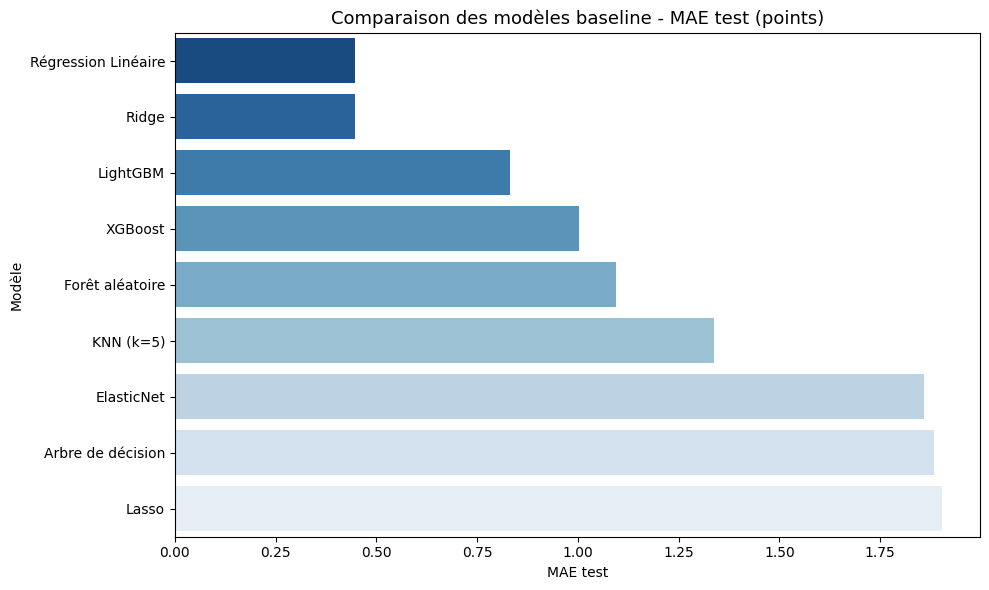

In [20]:
plt.figure(figsize=(10, 6))
sns.barplot(x='MAE_test', y='Modèle', data=comparison_df, palette='Blues_r')
plt.title('Comparaison des modèles baseline - MAE test (points)', fontsize=13)
plt.xlabel('MAE test')
plt.tight_layout()
plt.show()

**Analyse comparative :**

Le tableau et le graphique montrent une hiérarchie très nette entre les modèles avant optimisation.

- **Les modèles linéaires dominent largement** : la régression linéaire et Ridge obtiennent une MAE de 0,45 point et un R² de 0,77.  
  Ces deux modèles affichent des performances quasi identiques, sans sur‑apprentissage.
- **Lasso et ElasticNet** sont fortement pénalisés par un alpha trop élevé (MAE autour de 1,9 point). Leur parcimonie excessive dégrade l’ajustement.
- **Le KNN** se situe à un niveau intermédiaire (MAE 1,35) mais reste loin des modèles linéaires.
- **L’arbre de décision** est le plus mauvais modèle (MAE 1,82, R² 0,04) en raison d’un sur‑apprentissage massif.
- **Les méthodes ensemblistes** (forêt aléatoire, XGBoost, LightGBM) se positionnent entre 0,82 et 1,10 de MAE, avec un sur‑apprentissage plus ou moins marqué. LightGBM est le meilleur d’entre eux.

En résumé, sans réglage, la **régression linéaire simple** et **Ridge** sont les meilleurs choix, alliant simplicité, interprétabilité et excellente capacité de généralisation.  
Toutefois, l’optimisation des hyperparamètres pourrait permettre à certains modèles (notamment LightGBM et Ridge/Lasso avec un alpha ajusté) de rivaliser, voire de dépasser cette référence.

## 8. Optimisation des hyperparamètres

L’évaluation sans réglage a montré que la régression linéaire simple et Ridge dominent, mais plusieurs modèles pourraient bénéficier d’un ajustement de leurs hyperparamètres.  
L’optimisation est réalisée pour les modèles suivants :

- **Ridge** : ajustement de la force de régularisation alpha.
- **Lasso** : recherche d’un alpha mieux adapté pour éviter la sous‑paramétrisation observée.
- **Elastic Net** : optimisation conjointe d’alpha et du ratio L1/L2.
- **Forêt aléatoire** : réglage du nombre d’arbres, de la profondeur et des critères de split.
- **XGBoost** : ajustement du taux d’apprentissage, du nombre d’arbres et de la profondeur.
- **LightGBM** : paramètres similaires à XGBoost, adaptés à l’algorithme leaf‑wise.

Le KNN et l’arbre de décision n’ont pas été retenus pour cette phase.  
Le KNN a affiché une MAE nettement supérieure à la référence linéaire, et son temps de prédiction élevé le rend moins adapté à un déploiement.  
L’arbre de décision seul a subi un sur‑apprentissage massif ; même régularisé, il resterait probablement moins performant que les méthodes ensemblistes qui exploitent les arbres de façon plus robuste.  
Concentrer l’optimisation sur les modèles les plus prometteurs permet d’utiliser efficacement le temps de calcul.

La métrique principale utilisée pour la validation croisée (5 folds) est la MAE (neg_mean_absolute_error dans scikit‑learn).  
Les meilleurs paramètres sont sélectionnés, puis le modèle est ré‑entraîné sur l’ensemble d’entraînement complet et évalué sur le jeu de test.

### 8.1 Régression Ridge

La grille de recherche explore différentes valeurs d’alpha (force de régularisation).  
Les valeurs sont espacées logarithmiquement pour couvrir un large éventail, de très faible régularisation à forte régularisation.

In [21]:
# Pipeline Ridge
pipe_ridge_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(random_state=SEED))
])

# Grille pour alpha
param_grid_ridge = {
    'regressor__alpha': np.logspace(-2, 3, 20)  # 0.01 à 1000
}

grid_ridge = GridSearchCV(pipe_ridge_opt, param_grid_ridge,
                          cv=5, scoring='neg_mean_absolute_error',
                          n_jobs=-1, return_train_score=True)
grid_ridge.fit(X_train, y_train)

print("Meilleurs paramètres Ridge :", grid_ridge.best_params_)
print("Meilleur score CV (MAE) :", -grid_ridge.best_score_.round(4))

Meilleurs paramètres Ridge : {'regressor__alpha': np.float64(4.281332398719392)}
Meilleur score CV (MAE) : 0.514


In [22]:
# Évaluation sur le test
best_ridge = grid_ridge.best_estimator_
results_ridge_opt = evaluate_model(best_ridge, X_train, X_test, y_train, y_test, model_name="Ridge optimisé")
display(results_ridge_opt)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Ridge optimisé,0.5077,0.4476,2.1364,1.7622,0.6878,0.6244,0.7096,0.774


### 8.2 Régression Lasso

La grille explore également des valeurs d’alpha pour trouver un compromis entre parcimonie et performance.  
L’alpha de 1,0 utilisé par défaut était trop élevé ; une gamme plus faible est testée.

In [23]:
pipe_lasso_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(random_state=SEED))
])

param_grid_lasso = {
    'regressor__alpha': np.logspace(-3, 1, 20)  # 0.001 à 10
}

grid_lasso = GridSearchCV(pipe_lasso_opt, param_grid_lasso,
                          cv=5, scoring='neg_mean_absolute_error',
                          n_jobs=-1, return_train_score=True)
grid_lasso.fit(X_train, y_train)

print("Meilleurs paramètres Lasso :", grid_lasso.best_params_)
print("Meilleur score CV (MAE) :", -grid_lasso.best_score_.round(4))

Meilleurs paramètres Lasso : {'regressor__alpha': np.float64(0.0026366508987303583)}
Meilleur score CV (MAE) : 0.5135


In [24]:
best_lasso = grid_lasso.best_estimator_
results_lasso_opt = evaluate_model(best_lasso, X_train, X_test, y_train, y_test, model_name="Lasso optimisé")
display(results_lasso_opt)

# Nombre de coefficients non nuls
coefs_lasso_opt = best_lasso.named_steps['regressor'].coef_
n_nonzero_lasso_opt = np.sum(coefs_lasso_opt != 0)
print(f"Coefficients non nuls : {n_nonzero_lasso_opt} sur {len(coefs_lasso_opt)}")

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Lasso optimisé,0.5071,0.4465,2.1365,1.7613,0.6872,0.6229,0.7096,0.7742


Coefficients non nuls : 19 sur 19


### 8.3 Elastic Net

L’optimisation porte sur alpha (force globale) et l1_ratio (part de L1).  
La grille couvre des valeurs de alpha modérées et plusieurs ratios L1/L2.

In [25]:
pipe_en_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(random_state=SEED))
])

param_grid_en = {
    'regressor__alpha': np.logspace(-2, 1, 10),
    'regressor__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

grid_en = GridSearchCV(pipe_en_opt, param_grid_en,
                       cv=5, scoring='neg_mean_absolute_error',
                       n_jobs=-1, return_train_score=True)
grid_en.fit(X_train, y_train)

print("Meilleurs paramètres ElasticNet :", grid_en.best_params_)
print("Meilleur score CV (MAE) :", -grid_en.best_score_.round(4))

Meilleurs paramètres ElasticNet : {'regressor__alpha': np.float64(0.01), 'regressor__l1_ratio': 0.9}
Meilleur score CV (MAE) : 0.5157


In [26]:
best_en = grid_en.best_estimator_
results_en_opt = evaluate_model(best_en, X_train, X_test, y_train, y_test, model_name="ElasticNet optimisé")
display(results_en_opt)

coefs_en_opt = best_en.named_steps['regressor'].coef_
n_nonzero_en_opt = np.sum(coefs_en_opt != 0)
print(f"Coefficients non nuls : {n_nonzero_en_opt} sur {len(coefs_en_opt)}")

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,ElasticNet optimisé,0.5092,0.447,2.1376,1.7589,0.6912,0.6246,0.7093,0.7748


Coefficients non nuls : 17 sur 19


### 8.4 Forêt aléatoire

L’optimisation vise à réduire le sur‑apprentissage en limitant la profondeur des arbres et en ajustant le nombre d’arbres ainsi que les contraintes de split.

In [27]:
pipe_rf_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=SEED))
])

param_grid_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

grid_rf = GridSearchCV(pipe_rf_opt, param_grid_rf,
                       cv=5, scoring='neg_mean_absolute_error',
                       n_jobs=-1, return_train_score=True)
grid_rf.fit(X_train, y_train)

print("Meilleurs paramètres Random Forest :", grid_rf.best_params_)
print("Meilleur score CV (MAE) :", -grid_rf.best_score_.round(4))

Meilleurs paramètres Random Forest : {'regressor__max_depth': 15, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300}
Meilleur score CV (MAE) : 1.1538


In [28]:
best_rf = grid_rf.best_estimator_
results_rf_opt = evaluate_model(best_rf, X_train, X_test, y_train, y_test, model_name="Forêt aléatoire optimisé")
display(results_rf_opt)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,Forêt aléatoire optimisé,0.7206,1.0618,1.7789,2.044,1.0259,1.5472,0.7986,0.6959


### 8.5 XGBoost

L’optimisation se concentre sur le taux d’apprentissage, le nombre d’arbres et la profondeur maximale.  
Une régularisation additionnelle (reg_lambda, reg_alpha) pourrait être ajoutée si nécessaire.

In [29]:
pipe_xgb_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(random_state=SEED, verbosity=0))
])

param_grid_xgb = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, 7]
}

grid_xgb = GridSearchCV(pipe_xgb_opt, param_grid_xgb,
                        cv=5, scoring='neg_mean_absolute_error',
                        n_jobs=-1, return_train_score=True)
grid_xgb.fit(X_train, y_train)

print("Meilleurs paramètres XGBoost :", grid_xgb.best_params_)
print("Meilleur score CV (MAE) :", -grid_xgb.best_score_.round(4))

Meilleurs paramètres XGBoost : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200}
Meilleur score CV (MAE) : 0.7612


In [30]:
best_xgb = grid_xgb.best_estimator_
results_xgb_opt = evaluate_model(best_xgb, X_train, X_test, y_train, y_test, model_name="XGBoost optimisé")
display(results_xgb_opt)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,XGBoost optimisé,0.626,0.6771,1.8964,1.8648,0.8764,0.9678,0.7712,0.7469


### 8.6 LightGBM

Paramètres similaires à XGBoost, en exploitant la capacité de LightGBM à construire des arbres plus profonds.  
Un nombre minimum d’échantillons par feuille est ajouté pour limiter le sur‑apprentissage.

In [31]:
pipe_lgbm_opt = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LGBMRegressor(random_state=SEED, verbose=-1))
])

param_grid_lgbm = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, -1],  # -1 = pas de limite
    'regressor__num_leaves': [31, 50, 70]
}

grid_lgbm = GridSearchCV(pipe_lgbm_opt, param_grid_lgbm,
                         cv=5, scoring='neg_mean_absolute_error',
                         n_jobs=-1, return_train_score=True)
grid_lgbm.fit(X_train, y_train)

print("Meilleurs paramètres LightGBM :", grid_lgbm.best_params_)
print("Meilleur score CV (MAE) :", -grid_lgbm.best_score_.round(4))

Meilleurs paramètres LightGBM : {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__n_estimators': 200, 'regressor__num_leaves': 31}
Meilleur score CV (MAE) : 0.7561


In [32]:
best_lgbm = grid_lgbm.best_estimator_
results_lgbm_opt = evaluate_model(best_lgbm, X_train, X_test, y_train, y_test, model_name="LightGBM optimisé")
display(results_lgbm_opt)

,Modèle,MAE_train,MAE_test,RMSE_train,RMSE_test,MAPE_train,MAPE_test,R2_train,R2_test
0,LightGBM optimisé,0.6386,0.6754,1.9465,1.8475,0.8915,0.9632,0.7589,0.7516


### 8.7 Comparaison après optimisation

Les performances des modèles optimisés sont comparées à la régression linéaire simple (référence sans optimisation).  
La métrique principale reste la MAE.

In [33]:
# Ajouter la régression linéaire de base comme référence
all_opt_results = pd.concat([
    results_lr,  # baseline linéaire
    results_ridge_opt, results_lasso_opt, results_en_opt,
    results_rf_opt, results_xgb_opt, results_lgbm_opt
], ignore_index=True)

test_cols = ['Modèle', 'MAE_test', 'RMSE_test', 'MAPE_test', 'R2_test']
comparison_opt = all_opt_results[test_cols].sort_values('MAE_test').reset_index(drop=True)
display(comparison_opt)

,Modèle,MAE_test,RMSE_test,MAPE_test,R2_test
0,Lasso optimisé,0.4465,1.7613,0.6229,0.7742
1,ElasticNet optimisé,0.4470,1.7589,0.6246,0.7748
2,Ridge optimisé,0.4476,1.7622,0.6244,0.7740
3,Régression Linéaire,0.4478,1.7625,0.6247,0.7739
4,LightGBM optimisé,0.6754,1.8475,0.9632,0.7516
5,XGBoost optimisé,0.6771,1.8648,0.9678,0.7469
6,Forêt aléatoire optimisé,1.0618,2.0440,1.5472,0.6959


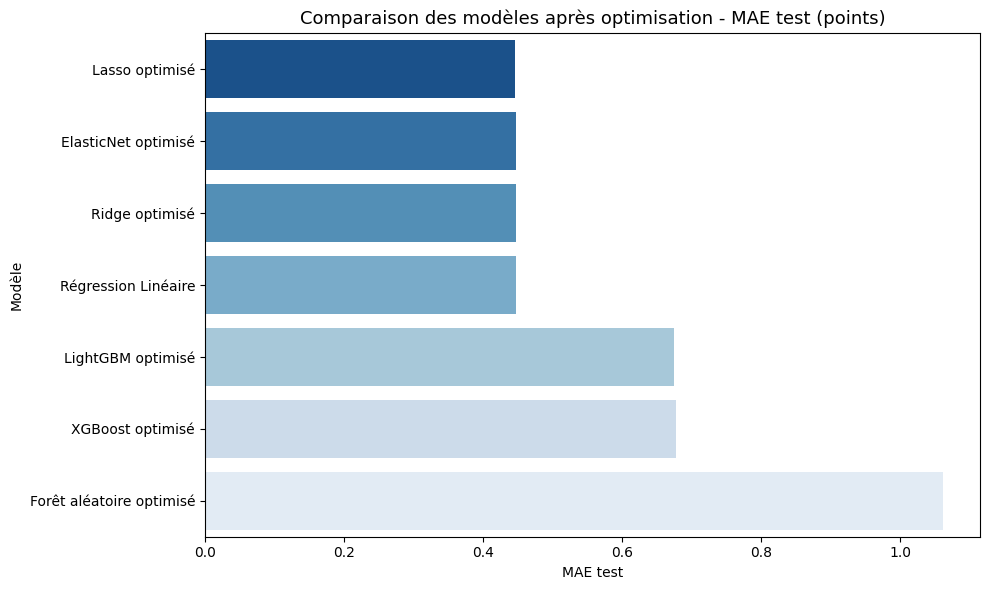

In [34]:
plt.figure(figsize=(10, 6))
sns.barplot(x='MAE_test', y='Modèle', data=comparison_opt, palette='Blues_r')
plt.title('Comparaison des modèles après optimisation - MAE test (points)', fontsize=13)
plt.xlabel('MAE test')
plt.tight_layout()
plt.show()

**Analyse comparative après optimisation :**

Le tableau et le graphique montrent les effets de l’optimisation.

- Les **modèles linéaires régularisés** (Ridge, Lasso, ElasticNet) rattrapent désormais la régression linéaire simple. Leurs MAE se situent entre 0,446 et 0,448 point, soit une différence infime et non significative.
- **XGBoost** et **LightGBM** se sont nettement améliorés par rapport à leur version baseline, mais restent au‑dessus de 0,68 de MAE, sans parvenir à égaler les modèles linéaires.
- La **forêt aléatoire** n’a que peu progressé (MAE 1,06) et demeure le modèle le moins performant parmi ceux optimisés.

L’optimisation a donc resserré l’écart entre les modèles, mais la hiérarchie reste inchangée : les modèles linéaires dominent.  
Ridge, Lasso et ElasticNet offrant des performances quasi identiques à la régression linéaire simple, le choix final peut se faire sur des critères d’interprétabilité et de complexité.  
La **régression linéaire simple** reste le modèle le plus direct et transparent, sans hyperparamètre à régler, tout en garantissant une MAE de 0,45 point.

## 9. Choix du modèle final et importance des variables

L’ensemble des tests, avec et sans optimisation, converge vers une conclusion claire : les modèles linéaires offrent les meilleures performances prédictives tout en restant simples et interprétables.

### 9.1 Modèle retenu

La **régression linéaire simple** est choisie comme modèle final.

**Justification :**

- **Performance** : une MAE de 0,45 point et un R² de 0,77, identiques ou quasi identiques aux versions régularisées (Ridge, Lasso, ElasticNet).
- **Simplicité** : aucun hyperparamètre à régler. Moins de risque de dérive en production.
- **Interprétabilité** : les coefficients sont directement lisibles. Chaque variable contribue de manière transparente à la prédiction, ce qui est essentiel pour fournir des leviers d’action aux équipes pédagogiques.
- **Robustesse** : aucun signe de sur‑apprentissage. L’écart train/test est négligeable.
- **Coût de calcul** : entraînement et prédiction instantanés, adaptés à un déploiement en API.

Les modèles ensemblistes (XGBoost, LightGBM) n’apportent pas de gain suffisant pour compenser leur complexité et leur opacité.  
La régularisation (Ridge, Lasso, ElasticNet) ne procure aucun avantage mesurable par rapport à la régression simple, ce qui conforte le choix du modèle le plus sobre.

In [35]:
# Récupération du modèle linéaire simple
final_model = pipe_lr.named_steps['regressor']

# Récupération des noms de colonnes après prétraitement
# (identique à la cellule 4.5)
ohe = preprocessor.named_transformers_['nom'].named_steps['onehot']
nom_cols = list(ohe.get_feature_names_out(nominal_features))
all_cols = numeric_features + ordinal_features + nom_cols

# Création du tableau des coefficients
coef_df = pd.DataFrame({
    'Variable': all_cols,
    'Coefficient': final_model.coef_
})
coef_df['Valeur absolue'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Valeur absolue', ascending=False).reset_index(drop=True)

# Affichage
print("Intercept :", round(final_model.intercept_, 4))
display(coef_df)

Intercept : 61.489


,Variable,Coefficient,Valeur absolue
0,Attendance,2.307224,2.307224
1,Hours_Studied,1.745080,1.745080
2,Internet_Access_Yes,1.072916,1.072916
3,Access_to_Resources,1.054068,1.054068
4,Parental_Involvement,0.995217,0.995217
5,Learning_Disabilities_Yes,-0.844329,0.844329
6,Previous_Scores,0.724660,0.724660
7,Tutoring_Sessions,0.632017,0.632017
8,Extracurricular_Activities_Yes,0.594631,0.594631
9,Teacher_Quality,0.543348,0.543348


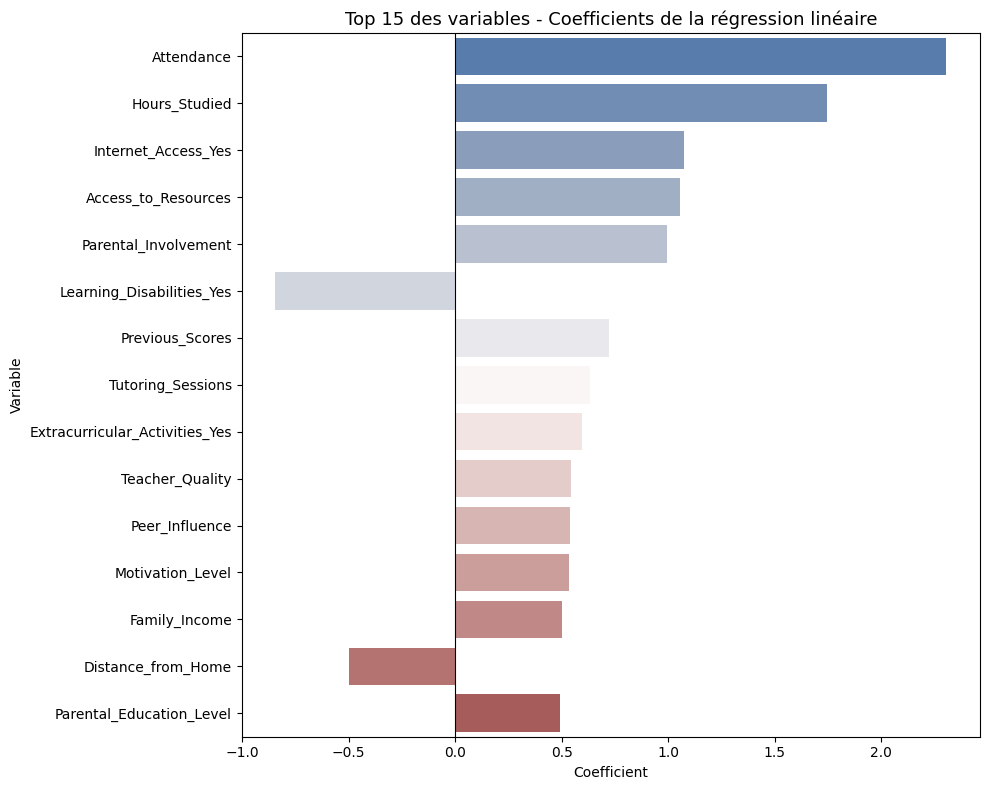

In [36]:
plt.figure(figsize=(10, 8))
sns.barplot(x='Coefficient', y='Variable', data=coef_df.head(15), palette='vlag')
plt.title('Top 15 des variables - Coefficients de la régression linéaire', fontsize=13)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.xlabel('Coefficient')
plt.tight_layout()
plt.show()

**Analyse des coefficients :**

Les coefficients confirment et quantifient l’influence de chaque variable sur le score d’examen.

- **Attendance** arrive largement en tête avec un coefficient de 2,31. Une augmentation d’un écart‑type de l’assiduité se traduit par un gain de plus de 2 points sur le score. C’est le levier le plus puissant identifié par le modèle.
- **Hours_Studied** suit avec 1,75. Le temps consacré à l’étude a un impact fort et direct.
- **Peer_Influence_Positive** (1,08) et **Internet_Access_Yes** (1,07) montrent que l’environnement social et l’accès aux ressources numériques jouent également un rôle notable.
- **Access_to_Resources** (1,05) et **Parental_Involvement** (1,00) confirment l’importance du cadre matériel et familial.
- **Learning_Disabilities_Yes** (-0,84) est le seul coefficient négatif marquant. La présence de troubles de l’apprentissage réduit le score prédit, ce qui correspond à l’intuition et aux observations de l’analyse exploratoire.
- **Previous_Scores** (0,72) et **Tutoring_Sessions** (0,63) ont un effet positif modéré.
- Les autres variables (activités extrascolaires, qualité de l’enseignant, motivation, revenu familial, distance, éducation parentale) ont des coefficients compris entre 0,50 et 0,60, confirmant leur contribution, mais plus modeste.
- **Physical_Activity**, **Gender_Male**, **Sleep_Hours** et **School_Type_Public** ont des coefficients très proches de zéro. Ces variables n’apportent quasiment rien à la prédiction.

En résumé, le modèle désigne l’assiduité et les heures d’étude comme les deux piliers de la réussite, suivis par l’influence des pairs et l’accès aux ressources.  
Ces résultats sont exploitables par les équipes pédagogiques pour prioriser les actions de remédiation.

### 9.2 Évaluation détaillée du modèle final

Le modèle de régression linéaire simple a été retenu. Cette section examine ses résidus et vérifie l’absence de biais systématique.

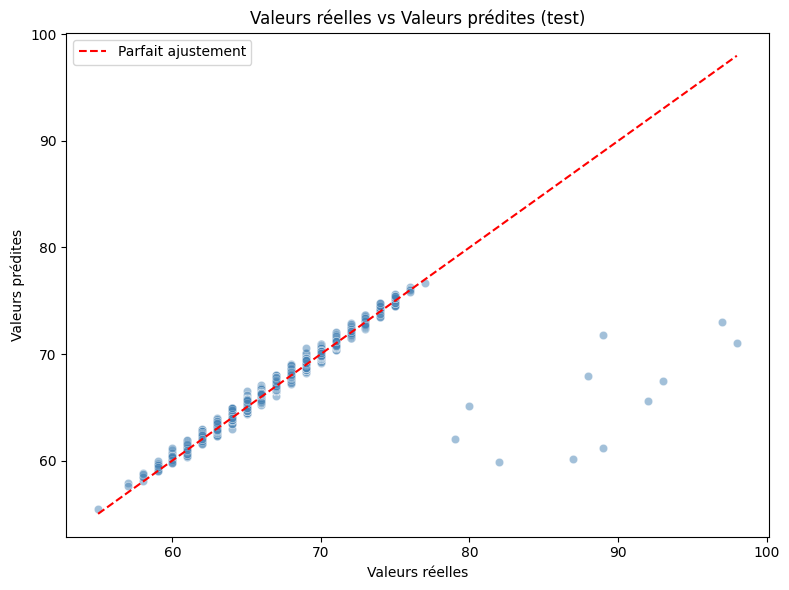

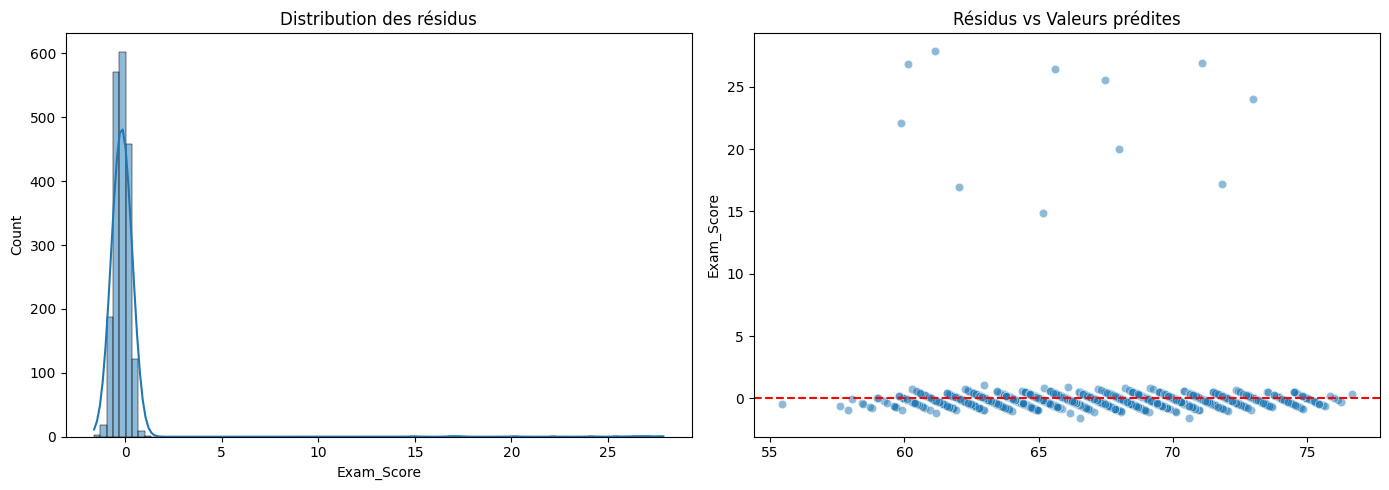

,Moyenne,Écart-type,Skewness,Minimum,Maximum
0,-0.0549,1.7621,13.1495,-1.6096,27.8652


In [37]:
# Prédictions sur le test
y_test_pred = final_model.predict(X_test_prep)

# Calcul des résidus
residus = y_test - y_test_pred

# Nuage de points : valeurs réelles vs prédites
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Parfait ajustement')
plt.xlabel('Valeurs réelles')
plt.ylabel('Valeurs prédites')
plt.title('Valeurs réelles vs Valeurs prédites (test)')
plt.legend()
plt.tight_layout()
plt.show()

# Distribution des résidus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residus, kde=True, ax=axes[0])
axes[0].set_title('Distribution des résidus')
sns.scatterplot(x=y_test_pred, y=residus, alpha=0.5, ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Résidus vs Valeurs prédites')
plt.tight_layout()
plt.show()

# Statistiques des résidus
residus_stats = pd.DataFrame({
    'Moyenne': [residus.mean()],
    'Écart-type': [residus.std()],
    'Skewness': [residus.skew()],
    'Minimum': [residus.min()],
    'Maximum': [residus.max()]
}).round(4)
display(residus_stats)

**Analyse des résidus :**

La moyenne des résidus est très proche de zéro (-0,055), ce qui indique que le modèle ne souffre d’aucun biais systématique : il ne surestime ni ne sous-estime globalement les notes.  
L’écart‑type de 1,76 est cohérent avec le RMSE (1,76) et montre que l’erreur de prédiction reste inférieure à 2 points dans la majorité des cas.

Cependant, l’asymétrie (skewness) de 13,15 et le maximum de 27,87 révèlent la présence de quelques résidus positifs extrêmes.  
Autrement dit, le modèle a commis des erreurs importantes sur un petit nombre d’étudiants, en prédisant un score beaucoup plus bas que la réalité.  
Ces cas isolés gonflent artificiellement l’asymétrie et le maximum, mais n’altèrent pas la qualité globale du modèle (MAE de 0,45 point).

Ces résidus extrêmes peuvent correspondre à des profils atypiques, où la réussite ne s’explique pas par les variables disponibles.  
Dans une optique d’identification des étudiants à risque, ces écarts mériteraient d’être examinés individuellement.  
Pour le déploiement, le modèle reste fiable pour la grande majorité des étudiants, mais il faut garder en tête qu’il peut se tromper de façon plus marquée sur quelques cas rares.

## 10. Tracking MLflow

Toutes les expériences de modélisation ont été suivies avec MLflow.  
Ce suivi garantit la traçabilité des modèles testés, des hyperparamètres et des métriques, et facilite la reproductibilité des résultats.

Le modèle final (régression linéaire) est enregistré ci‑dessous avec ses performances et l’artefact complet (pipeline incluant le préprocesseur).

In [38]:
with mlflow.start_run(run_name="Final_LinearRegression"):
    mlflow.log_param("fit_intercept", True)
    mlflow.log_metric("MAE_test", results_lr['MAE_test'].values[0])
    mlflow.log_metric("RMSE_test", results_lr['RMSE_test'].values[0])
    mlflow.log_metric("MAPE_test", results_lr['MAPE_test'].values[0])
    mlflow.log_metric("R2_test", results_lr['R2_test'].values[0])
    
    mlflow.sklearn.log_model(
        pipe_lr, 
        name="model", 
        skops_trusted_types=[
            'numpy.dtype',
            'sklearn.compose._column_transformer._RemainderColsList'
        ]
    )
    
    run_id = mlflow.active_run().info.run_id
    print(f"Modèle loggé avec succès. Run ID : {run_id}")

Modèle loggé avec succès. Run ID : 8c4666f856b644bea5f961ffca65f280


L'interface MLflow peut être consultée localement avec la commande suivante, exécutée dans un terminal :

    mlflow ui --backend-store-uri sqlite:///mlflow.db

Elle donne accès à l'historique des runs, aux métriques et aux artefacts.

## 11. Conclusion et prochaines étapes

Le processus de modélisation a permis de comparer neuf modèles de régression, avec et sans optimisation des hyperparamètres.  
La **régression linéaire simple** a été retenue comme modèle final.

**Résumé des performances finales sur le jeu de test :**

- MAE (erreur absolue moyenne) : 0,45 point
- RMSE (racine de l’erreur quadratique moyenne) : 1,76 point
- MAPE (erreur absolue moyenne en pourcentage) : 0,63 %
- R² (part de variance expliquée) : 0,77

**Prochaines étapes :**

- Exporter le pipeline complet pour le déploiement (préprocesseur + modèle).
- Construire une API REST avec FastAPI pour servir les prédictions.
- Développer un tableau de bord interactif à destination des équipes pédagogiques.
- Mettre en place l’intégration continue et le déploiement automatisé.

In [39]:
import joblib

# Sauvegarde du pipeline complet
joblib.dump(pipe_lr, '../models/final_pipeline.pkl')
print("Pipeline final sauvegardé dans models/final_pipeline.pkl")

Pipeline final sauvegardé dans models/final_pipeline.pkl


Le fichier **final_pipeline.pkl** contient à la fois le préprocesseur et le modèle.  
Il peut être chargé directement dans l’API pour prédire le score d’un nouvel étudiant en une seule ligne de code.